## Explorando e vetorizando os dados textuais

### Conhecendo os dados

In [1]:
import pandas as pd

In [2]:
dados =  pd.read_csv('https://raw.githubusercontent.com/alura-cursos/nlp_analise_sentimento/refs/heads/main/Dados/dataset_avaliacoes.csv')

In [3]:
dados

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo
...,...,...,...,...
15496,61836,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,4,positivo
15497,19503,"O produto seca o cabelo, mas tem que passar di...",2,negativo
15498,52712,"Muito simples de mexer, o manual explica direi...",5,positivo
15499,10874,"Produto muito bom, exatamente como na internet...",4,positivo


In [4]:
dados.shape

(15501, 4)

In [5]:
dados['sentimento'].value_counts()

,count
sentimento,
positivo,7890
negativo,7611


In [6]:
print('positiva \n')

dados.avaliacao[0]

positiva 



'Esse smartphone superou minhas expectativas, recomendo'

In [7]:
print('negativa \n')

dados.avaliacao[2]

negativa 



'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

### Transformando textos em dados numéricos

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ['Comprei um produto ótimo', 'Comprei um produto ruim']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [9]:
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [10]:
matriz_sparca = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vetorizar.get_feature_names_out())

In [11]:
matriz_sparca

,comprei,produto,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


In [12]:
vetorizar = CountVectorizer(lowercase=False)
bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

(15501, 23352)


In [13]:
vetorizar = CountVectorizer(lowercase=False, max_features=50)
bag_of_words = vetorizar.fit_transform(dados.avaliacao)
print(bag_of_words.shape)

(15501, 50)


In [14]:
matriz_sparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vetorizar.get_feature_names_out())

In [15]:
matriz_sparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


### Classificando os sentimentos

In [16]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, dados.sentimento, random_state=4978)

In [17]:
from sklearn.linear_model import LogisticRegression

regressao_logistica = LogisticRegression()
regressao_logistica.fit(X_treino, y_treino)
acuracia = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia: {acuracia}')

Acurácia: 0.7982456140350878


In [18]:
def classificar_texto(dados, sentimentos, coluna_texto):
  vetorizar = CountVectorizer(lowercase=False, max_features=50)
  bag_of_words = vetorizar.fit_transform(dados[coluna_texto])

  X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, dados[sentimentos], random_state=4978)

  regressao_logistica = LogisticRegression()
  regressao_logistica.fit(X_treino, y_treino)
  acuracia = regressao_logistica.score(X_teste, y_teste)
  return f'Acurácia: {acuracia *100:.2f}%'

In [19]:
classificar_texto(dados, 'sentimento', 'avaliacao')

'Acurácia: 79.82%'

## Explorando a frequência e o sentimento

### Visualizando as palavras mais frequentes nas avaliações

In [20]:
from wordcloud import WordCloud

In [21]:
todas_palavras = [texto for texto in dados.avaliacao]

In [22]:
todas_palavras

['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [23]:
todas_palavras = ' '.join([texto for texto in dados.avaliacao])

In [24]:
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [25]:
nuvem_palavras = WordCloud().generate(todas_palavras)

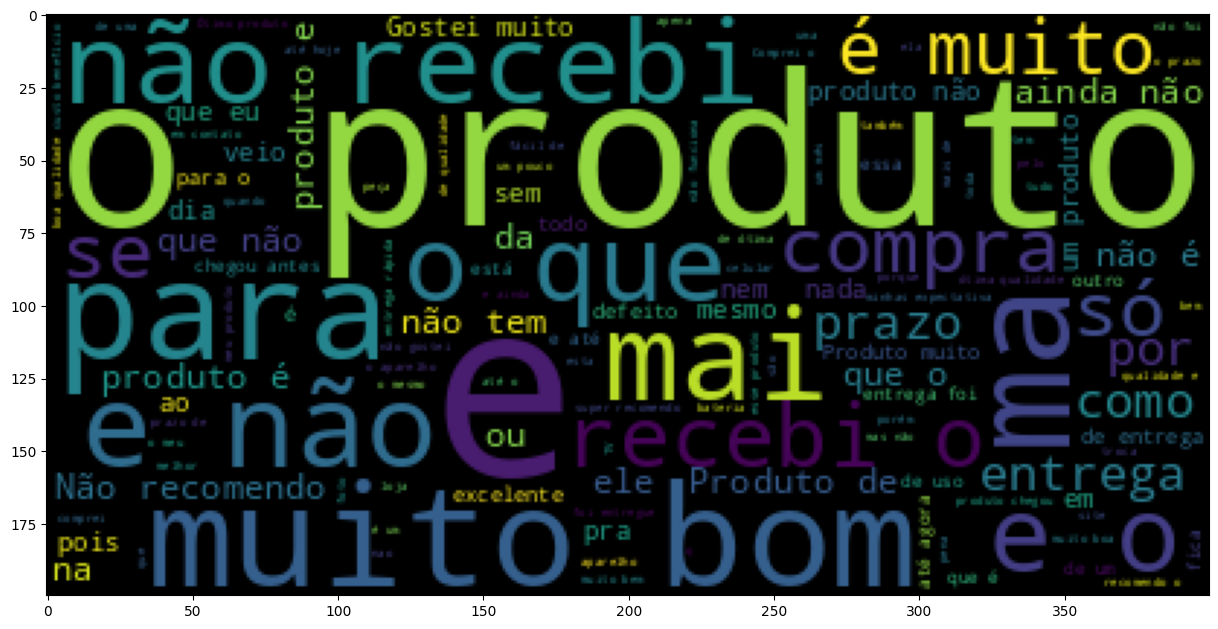

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))
plt.imshow(nuvem_palavras)
plt.show()

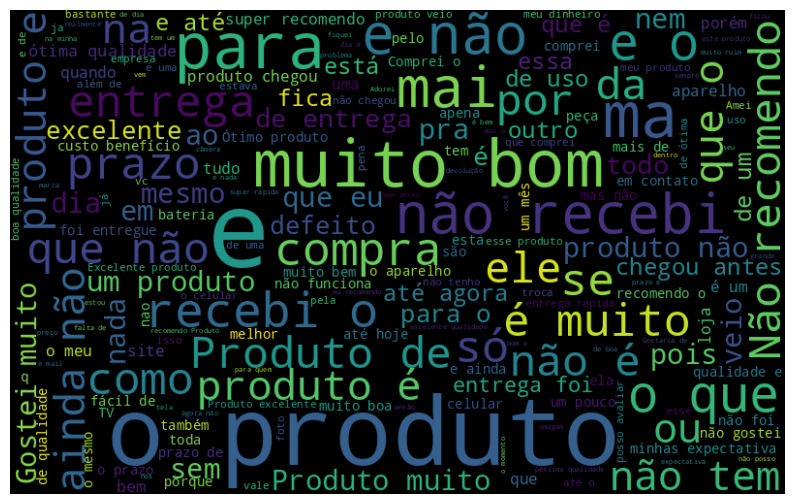

In [27]:
nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110).generate(todas_palavras)
plt.figure(figsize=(10,7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show()

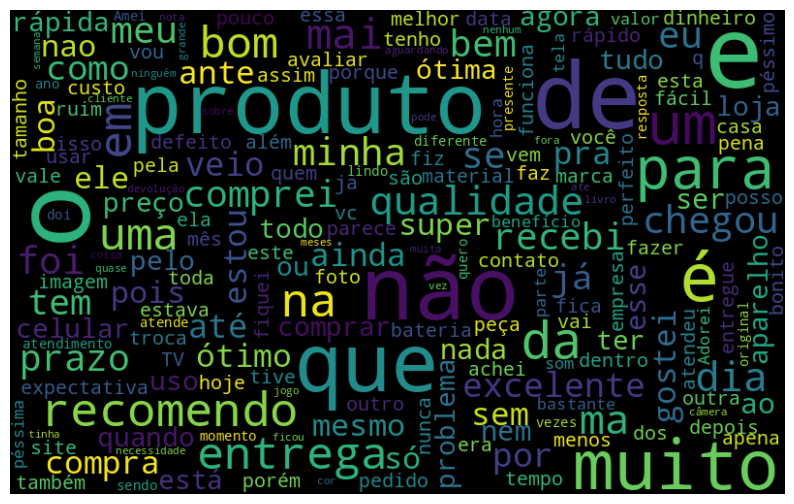

In [28]:
nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(todas_palavras)
plt.figure(figsize=(10,7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show()

### Analisando palavras por sentimento

In [29]:
def nuvem_palavras(texto, coluna_texto, sentimento):
  texto_sentimento = texto.query(f"sentimento == '{sentimento}' ")[coluna_texto]

  texto_unido = ' '.join(texto_sentimento)

  nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(texto_unido)
  plt.figure(figsize=(10,7))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()

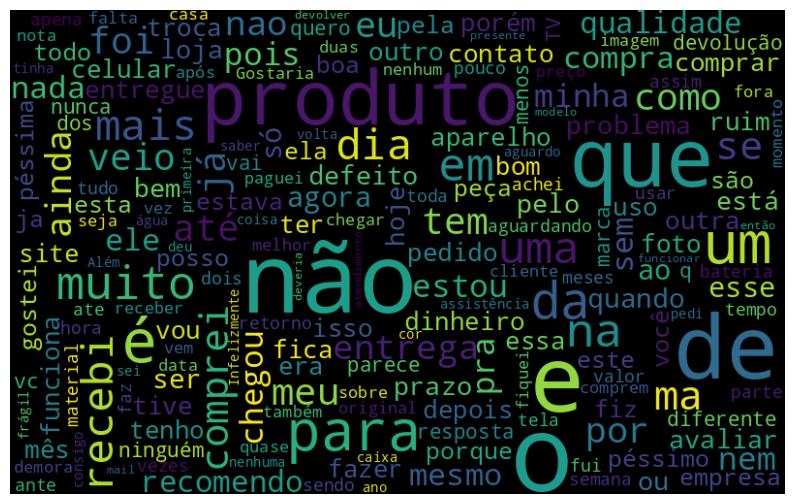

In [30]:
nuvem_palavras(dados, 'avaliacao', 'negativo')

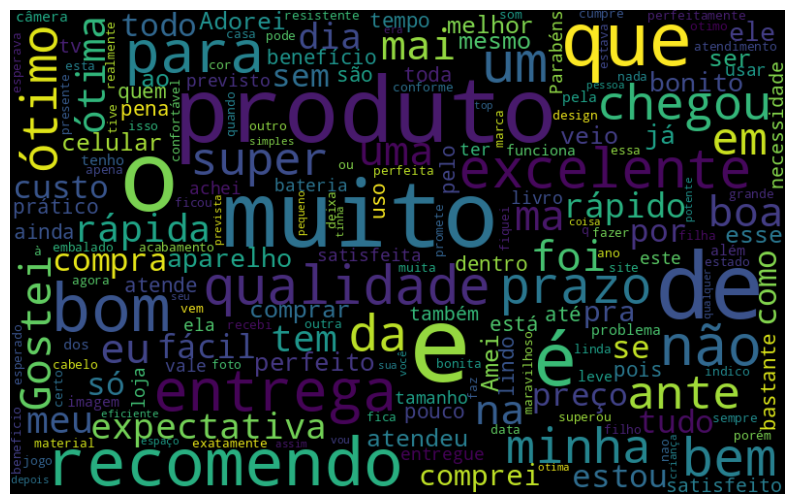

In [31]:
nuvem_palavras(dados, 'avaliacao', 'positivo')

### Dividindo o texto em unidades menores

In [32]:
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [33]:
frases = ['um produto bom', 'um produto ruim']

frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'um produto bom': 1, 'um produto ruim': 1})

In [34]:
from nltk import tokenize

frase = ' O produto é excelente e a entrega foi muito rápida!'
token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
print(token_frase)

['O', 'produto', 'é', 'excelente', 'e', 'a', 'entrega', 'foi', 'muito', 'rápida!']


### Analisando a frequência das palavras

In [35]:
token_frase = token_espaco.tokenize(todas_palavras)

In [36]:
token_frase

['Esse',
 'smartphone',
 'superou',
 'minhas',
 'expectativas,',
 'recomendo',
 'o',
 'cheiro',
 'e',
 'muito',
 'desagradavel!!',
 'pra',
 'quem',
 'se',
 'incomoda',
 'nao',
 'recomendoo..',
 'Eu',
 'fiz',
 'a',
 'compra',
 'a',
 'loja',
 'não',
 'entregou',
 'o',
 'produto,',
 'a',
 'compra',
 'foi',
 'feita',
 'no',
 'cartão',
 'de',
 'credito',
 'e',
 'ate',
 'o',
 'momento',
 'a',
 'loja',
 'também',
 'nao',
 'me',
 'devolveu',
 'o',
 'valor',
 'da',
 'compra.',
 'Atendeu',
 'minhas',
 'expectativas,',
 'só',
 'achei',
 'a',
 'luz',
 'ruim,',
 'mas',
 'nada',
 'que',
 'dificulte',
 'seu',
 'funcionamento.',
 'Gostei',
 'muito,',
 'só',
 'achei',
 'que',
 'ficou',
 'a',
 'desejar',
 'a',
 'qualidade',
 'das',
 'fotos.',
 'Achei',
 'que',
 'fosse',
 'bem',
 'melhor',
 '.',
 'Comprei',
 'o',
 'produto',
 'e',
 'ñ',
 'tinha',
 'para',
 'entrega',
 'isso',
 'não',
 'foi',
 'legal!!!!!!',
 'o',
 'produto',
 'pode',
 'até',
 'ser',
 'bom',
 ',mais',
 'só',
 'posso',
 'avalia-lo',
 'depo

In [37]:
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [38]:
df_frequencia = pd.DataFrame({'Palavra': list(frequencia.keys()),
                              'Frequencia': list(frequencia.values())})

In [39]:
df_frequencia.sort_values(by='Frequencia', ascending=False).head(10)

,Palavra,Frequencia
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


In [40]:
df_frequencia.nlargest(columns='Frequencia', n=10)

,Palavra,Frequencia
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


/tmp/ipython-input-234293863.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


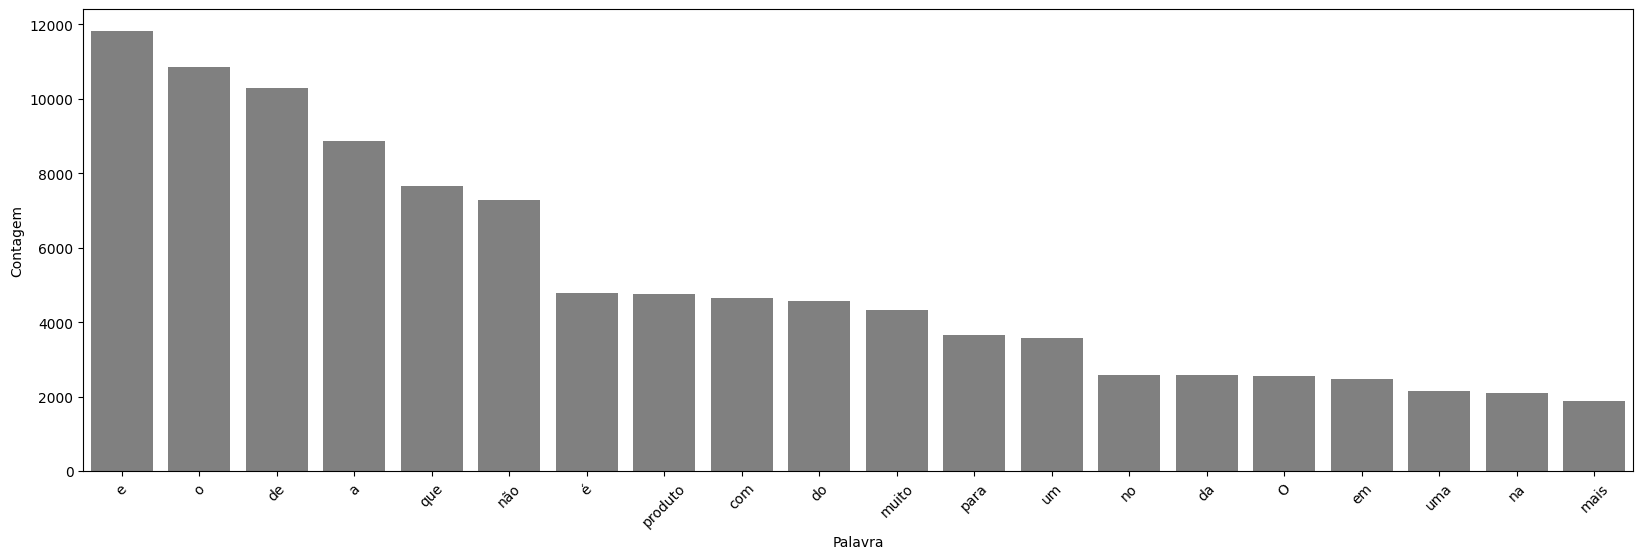

In [41]:
import seaborn as sns

plt.figure(figsize=(20,6))

ax = sns.barplot(data=df_frequencia.nlargest(columns='Frequencia', n=20), x='Palavra', y='Frequencia', color='gray')
ax.set_ylabel('Contagem')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.show()

In [42]:
def grafico_frequencia(texto, avaliacoes, npalavras):
  todas_palavras = ' '.join([texto for texto in dados[avaliacoes]])

  token_espaco = tokenize.WhitespaceTokenizer()
  token_frase = token_espaco.tokenize(todas_palavras)
  frequencia = nltk.FreqDist(token_frase)

  df_frequencia = pd.DataFrame({'Palavra': list(frequencia.keys()),
                                'Frequencia': list(frequencia.values())})

  plt.figure(figsize=(20,6))

  ax = sns.barplot(data=df_frequencia.nlargest(columns='Frequencia', n=npalavras), x='Palavra', y='Frequencia', color='gray')
  ax.set_ylabel('Contagem')
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

  plt.show()

/tmp/ipython-input-2667435855.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


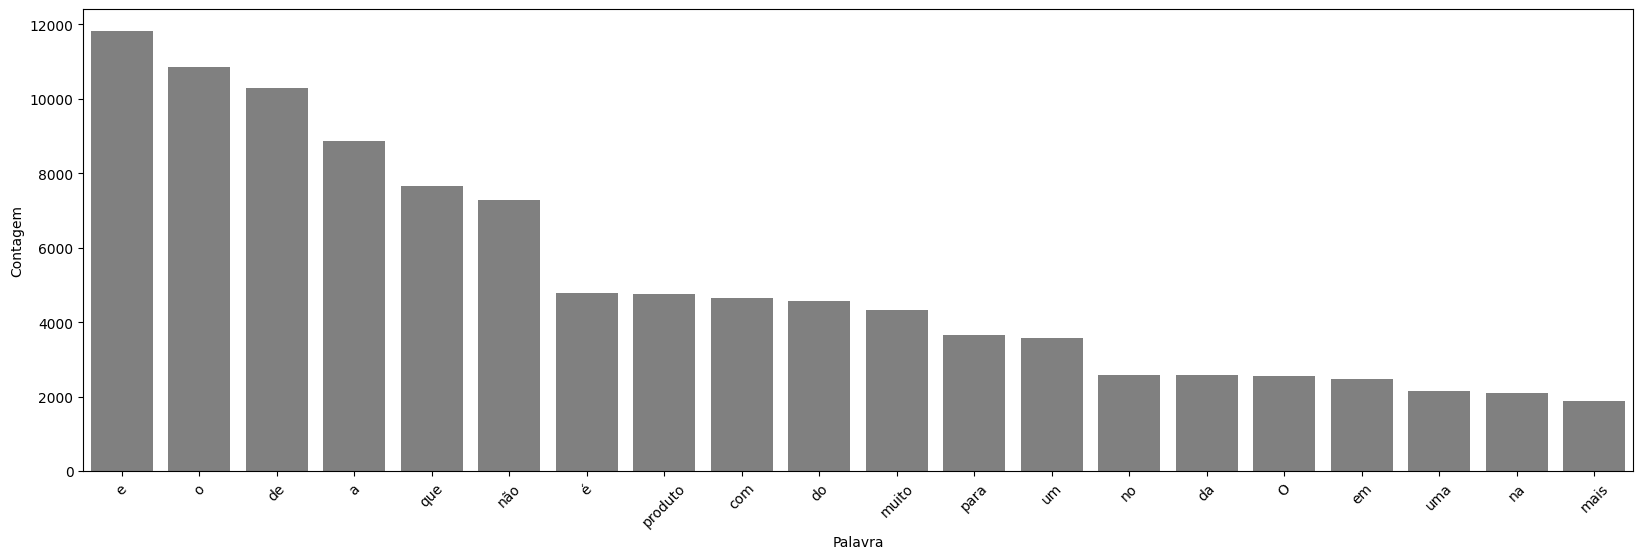

In [43]:
grafico_frequencia(dados, 'avaliacao', 20)

## Limpando e normalizando dados textuais

### Removendo stopwords

In [44]:
palavras_irrelevantes  = nltk.corpus.stopwords.words('portuguese')

In [45]:
palavras_irrelevantes

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'é',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'éramos',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'está',
 'estamos',
 'estão',
 'estar',
 'estas',
 'estava',
 'estavam',
 'estávamos',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estivéramos',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéssemos',
 'estou',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'fôramos',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fôssemos',
 'fui',
 'há',
 'haja',
 'hajam',
 'hajamos',
 'hão',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houverá',
 'houveram',
 'houvéramos',
 'houverão',
 'houverei',
 'houverem',
 'hou

In [46]:
frase_processada = []

for opiniao in dados.avaliacao:
  palavras_texto = token_espaco.tokenize(opiniao)
  nova_frase = [palavra for palavra in palavras_texto if palavra not in palavras_irrelevantes]
  frase_processada.append(' '.join(nova_frase))

dados['tratameto_1'] = frase_processada

In [47]:
dados

,ID_avaliacao,avaliacao,nota,sentimento,tratameto_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo"
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo..."
...,...,...,...,...,...
15496,61836,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,4,positivo,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...
15497,19503,"O produto seca o cabelo, mas tem que passar di...",2,negativo,"O produto seca cabelo, passar diversas vezes m..."
15498,52712,"Muito simples de mexer, o manual explica direi...",5,positivo,"Muito simples mexer, manual explica direitinho..."
15499,10874,"Produto muito bom, exatamente como na internet...",4,positivo,"Produto bom, exatamente internet chegou antes ..."


In [48]:
dados['avaliacao'][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [49]:
dados['tratameto_1'][0]

'Esse smartphone superou expectativas, recomendo'

In [50]:
classificar_texto(dados, 'sentimento', 'tratameto_1')

'Acurácia: 81.09%'

/tmp/ipython-input-2667435855.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


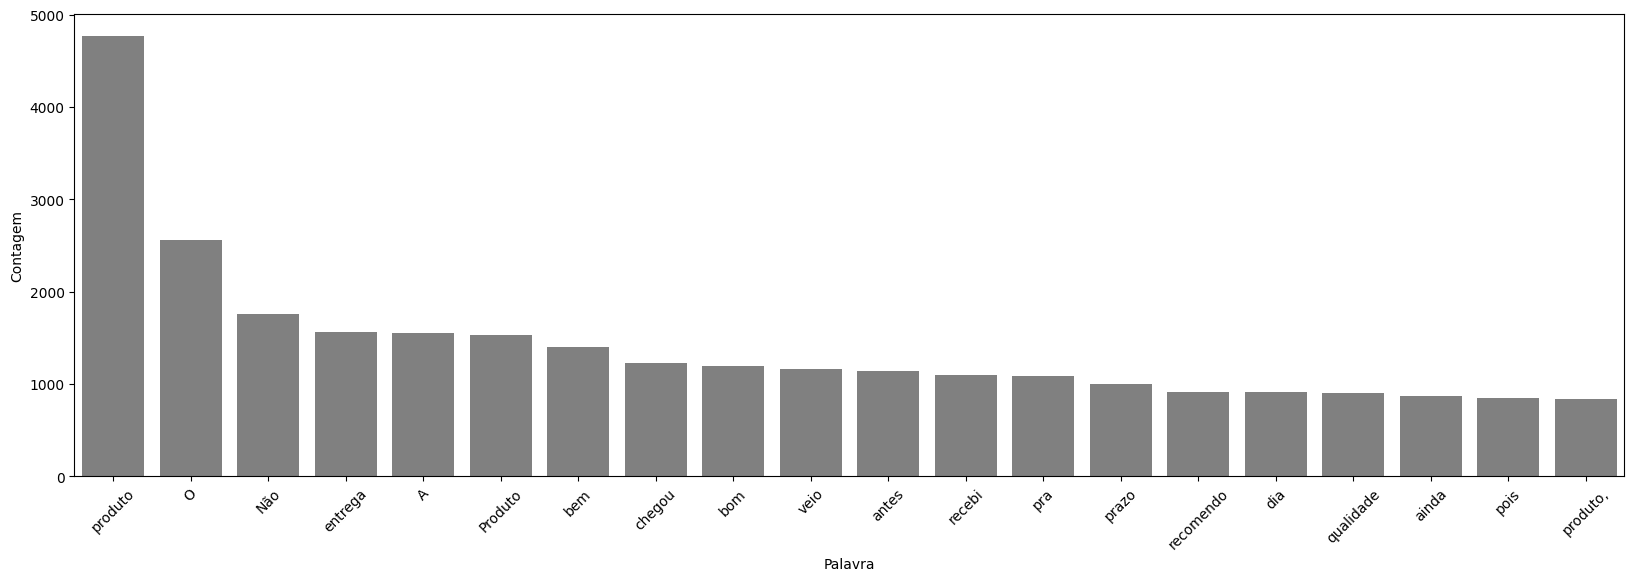

In [51]:
grafico_frequencia(dados, 'tratameto_1', 20)

### Removendo pontuação

In [76]:
frase = 'Esse smartphone superou expectativas, recomendo,'

token_pontuacao = tokenize.WordPunctTokenizer()
token_frase = token_pontuacao.tokenize(frase)
print(token_frase)

['Esse', 'smartphone', 'superou', 'expectativas', ',', 'recomendo', ',']


In [53]:
frase_processada = []

for opiniao in dados.tratameto_1:
  palavras_texto = token_pontuacao.tokenize(opiniao)
  nova_frase = [palavra for palavra in palavras_texto if palavra.isalpha() and palavra not in palavras_irrelevantes]
  frase_processada.append(' '.join(nova_frase))

dados['tratamento_2'] = frase_processada

In [54]:
dados

,ID_avaliacao,avaliacao,nota,sentimento,tratameto_1,tratamento_2
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...
...,...,...,...,...,...,...
15496,61836,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,4,positivo,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,Bommm mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...
15497,19503,"O produto seca o cabelo, mas tem que passar di...",2,negativo,"O produto seca cabelo, passar diversas vezes m...",O produto seca cabelo passar diversas vezes me...
15498,52712,"Muito simples de mexer, o manual explica direi...",5,positivo,"Muito simples mexer, manual explica direitinho...",Muito simples mexer manual explica direitinho ...
15499,10874,"Produto muito bom, exatamente como na internet...",4,positivo,"Produto bom, exatamente internet chegou antes ...",Produto bom exatamente internet chegou antes p...


/tmp/ipython-input-2667435855.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


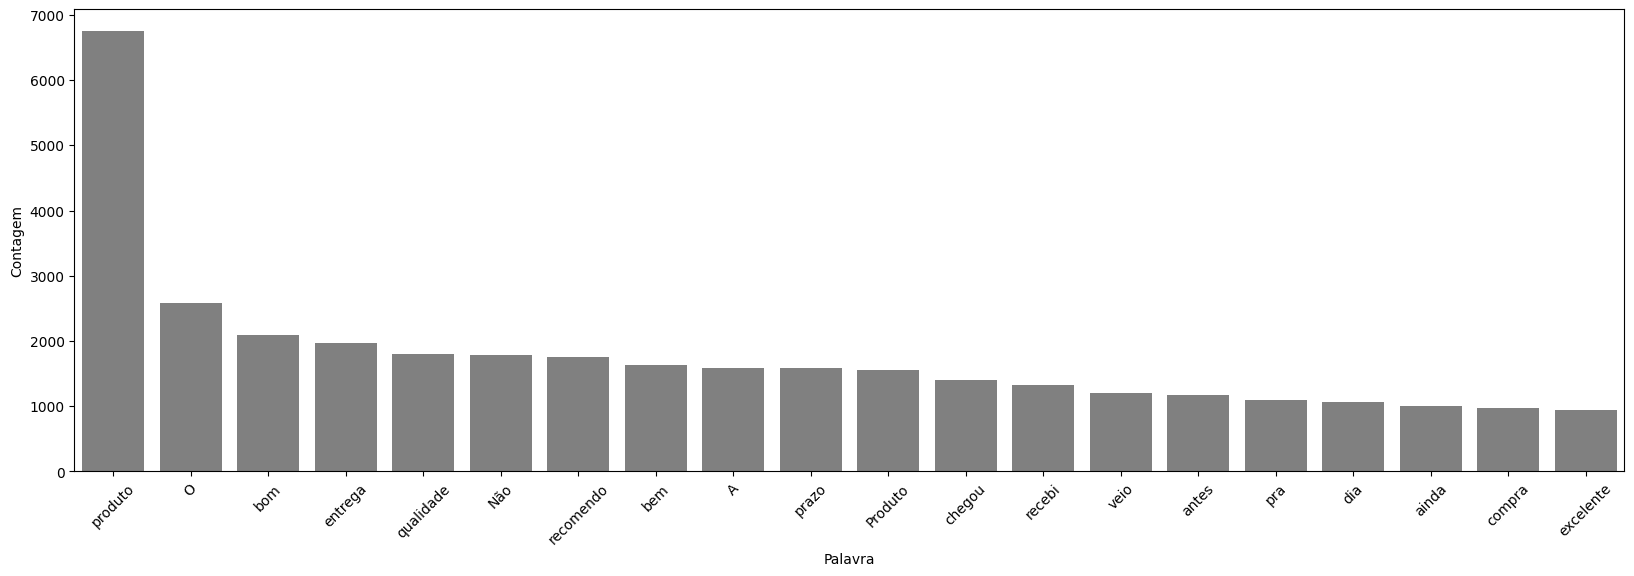

In [55]:
grafico_frequencia(dados, 'tratamento_2', 20)

### Removendo acentuação

In [56]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.1 MB/s eta 0:00:00


In [57]:
import unidecode

frase = 'Um aparelho ótima performance preço bem menor outros aparelhos marcas conhecidas performance semelhante'

teste = unidecode.unidecode(frase)
print(teste)

Um aparelho otima performance preco bem menor outros aparelhos marcas conhecidas performance semelhante


In [58]:
sem_acentos = [unidecode.unidecode(texto) for texto in dados.tratamento_2]

In [59]:
stopwords_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [60]:
dados['tratamento_3'] = sem_acentos

frase_processada = []

for opiniao in dados.tratamento_3:
  palavras_texto = token_pontuacao.tokenize(opiniao)
  nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
  frase_processada.append(' '.join(nova_frase))

dados['tratamento_4'] = frase_processada

In [61]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratameto_1,tratamento_2,tratamento_3,tratamento_4
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...


In [62]:
dados['tratamento_2'][70]

'Melhor compra fiz últimos tempos Produto barato útil Produto robusto leve O teclado proporciona digitação confortável mouse preciso O teclado mouse usam apenas receptor economizando número portas USB computador Me livrei incomodo fios espaço trabalho ficou limpo harmonioso Ademais tudo parece bastante durável safisfeito Recomendo todos'

In [63]:
dados['tratamento_4'][70]

'Melhor compra fiz ultimos tempos Produto barato util Produto robusto leve O teclado proporciona digitacao confortavel mouse preciso O teclado mouse usam apenas receptor economizando numero portas USB computador Me livrei incomodo fios espaco trabalho ficou limpo harmonioso Ademais tudo parece bastante duravel safisfeito Recomendo todos'

/tmp/ipython-input-2667435855.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


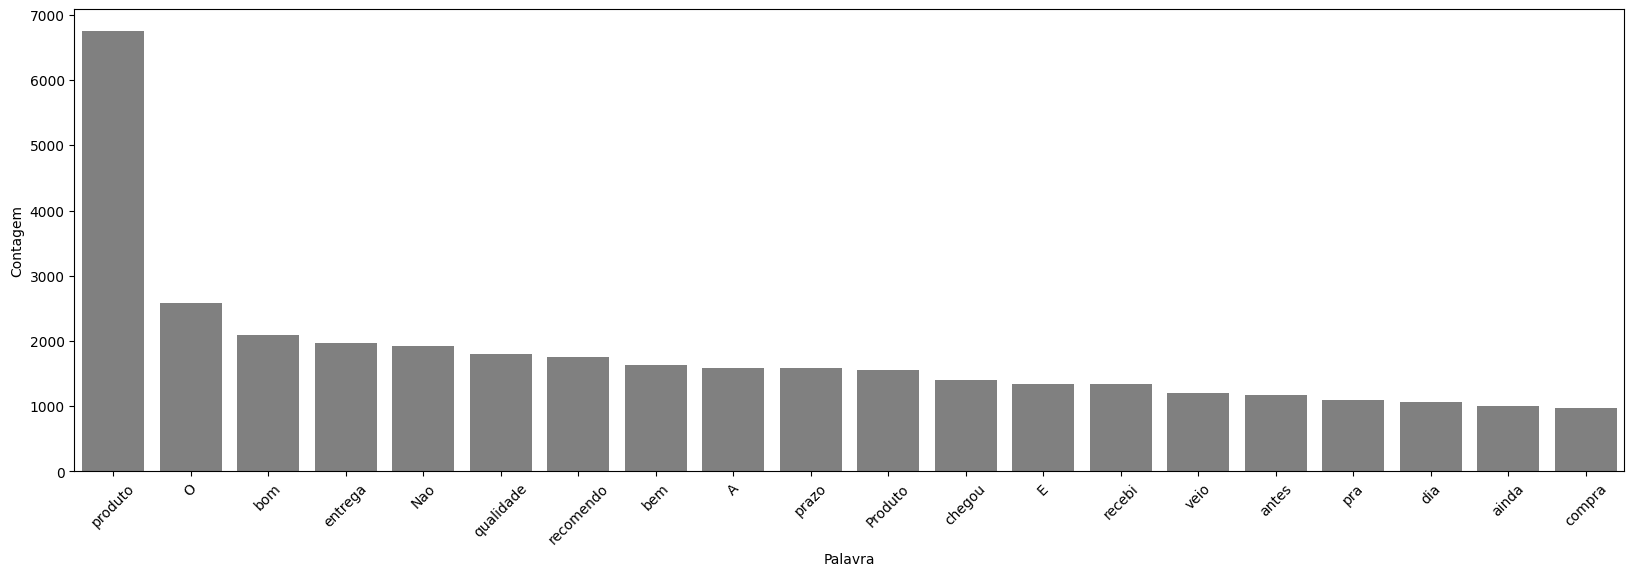

In [64]:
grafico_frequencia(dados, 'tratamento_4', 20)

### Uniformizando o texto

In [65]:
frase_processada = []

for opiniao in dados.tratamento_3:
  opiniao = opiniao.lower()
  palavras_texto = token_pontuacao.tokenize(opiniao)
  nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
  frase_processada.append(' '.join(nova_frase))

dados['tratamento_4'] = frase_processada

In [66]:
dados

,ID_avaliacao,avaliacao,nota,sentimento,tratameto_1,tratamento_2,tratamento_3,tratamento_4
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...
...,...,...,...,...,...,...,...,...
15496,61836,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,4,positivo,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,Bommm mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,Bommm mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,bommm mmmmmmmmmmmmmmmm mmmmmmmmmmmmmmmmmmmmmmm...
15497,19503,"O produto seca o cabelo, mas tem que passar di...",2,negativo,"O produto seca cabelo, passar diversas vezes m...",O produto seca cabelo passar diversas vezes me...,O produto seca cabelo passar diversas vezes me...,produto seca cabelo passar diversas vezes mesm...
15498,52712,"Muito simples de mexer, o manual explica direi...",5,positivo,"Muito simples mexer, manual explica direitinho...",Muito simples mexer manual explica direitinho ...,Muito simples mexer manual explica direitinho ...,simples mexer manual explica direitinho funcio...
15499,10874,"Produto muito bom, exatamente como na internet...",4,positivo,"Produto bom, exatamente internet chegou antes ...",Produto bom exatamente internet chegou antes p...,Produto bom exatamente internet chegou antes p...,produto bom exatamente internet chegou antes p...


/tmp/ipython-input-2667435855.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


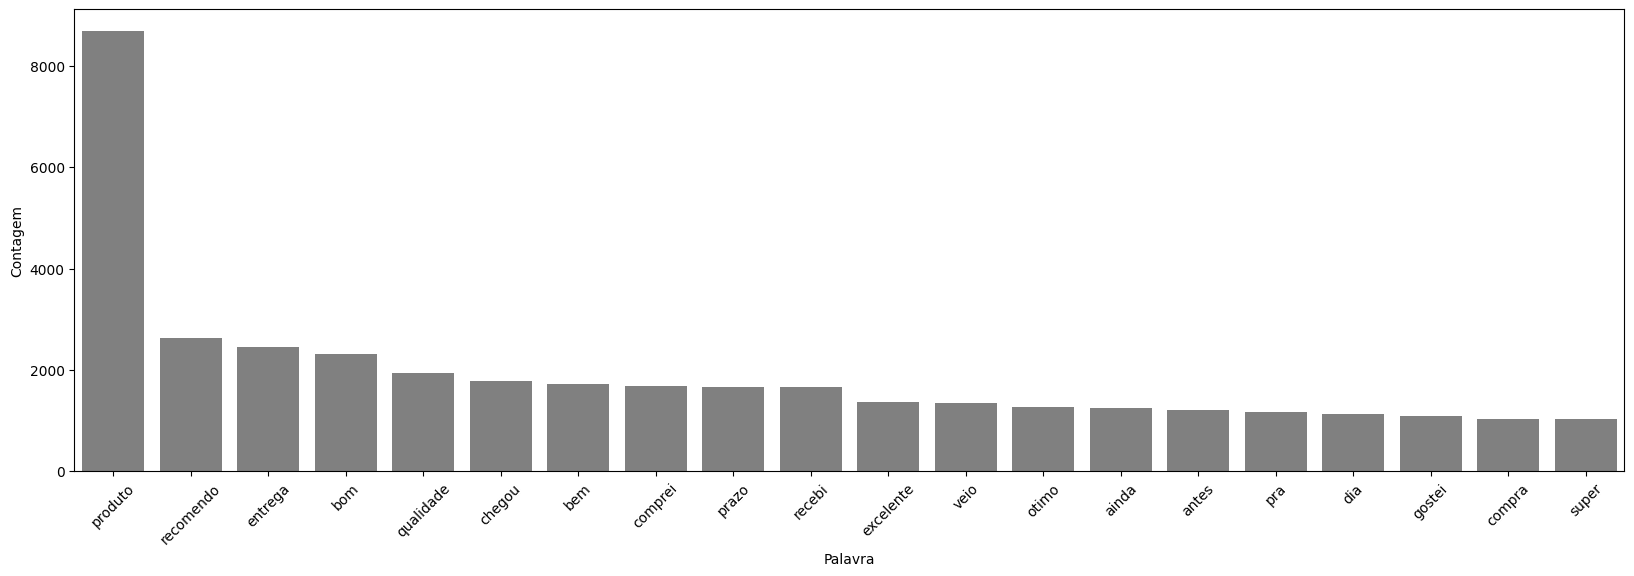

In [67]:
grafico_frequencia(dados, 'tratamento_4', 20)

In [68]:
classificar_texto(dados, 'sentimento', 'tratamento_4')

'Acurácia: 83.75%'

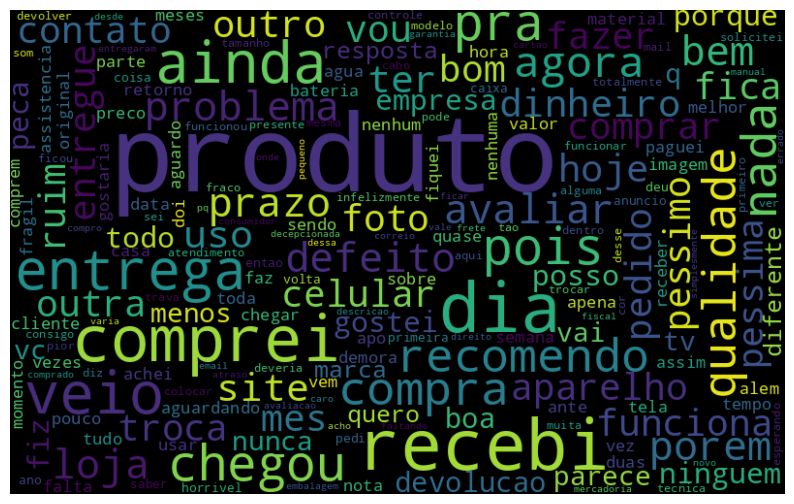

In [69]:
nuvem_palavras(dados, 'tratamento_4', 'negativo')

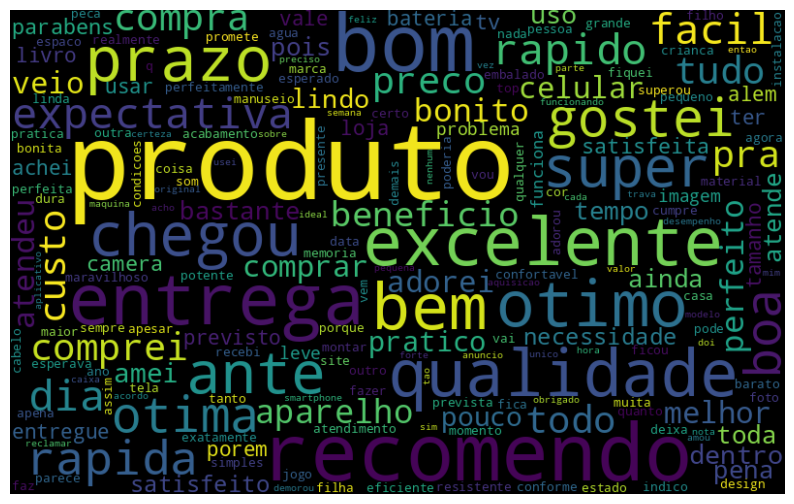

In [70]:
nuvem_palavras(dados, 'tratamento_4', 'positivo')

## Utilizando outras técnicas de processamento de texto

### Simplificando as palavras

In [71]:
stemmer = nltk.RSLPStemmer()

stemmer.stem('gostei')

'gost'

In [72]:
stemmer.stem('gostado')

'gost'

In [73]:
stemmer.stem('gostei muito')

'gostei muit'

In [77]:
frase_processada = []

for opiniao in dados.tratamento_4:
  palavras_texto = token_pontuacao.tokenize(opiniao)
  nova_frase = [stemmer.stem(palavra) for palavra in palavras_texto]
  frase_processada.append(' '.join(nova_frase))

dados['tratamento_5'] = frase_processada

In [78]:
dados.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratameto_1,tratamento_2,tratamento_3,tratamento_4,tratamento_5
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo,smartphon super expect recom
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheir desagrada pra incomod recomendo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...,fiz compr loj entreg produt compr feit carta c...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...,atend expect ach luz ruim nad dificult funcion
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...,gost ach fic desej qual fot ach bem melhor


In [80]:
print(dados["tratamento_4"][3])

atendeu expectativas achei luz ruim nada dificulte funcionamento


In [81]:
print(dados["tratamento_5"][3])

atend expect ach luz ruim nad dificult funcion


In [82]:
classificar_texto(dados, 'sentimento', 'tratamento_5')

'Acurácia: 85.11%'

### Determinando a importância das palavras

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
frases = ['Comprei um ótimo produto', 'Comprei um produto péssimo']

tfidf = TfidfVectorizer(lowercase=False, max_features=50)
matriz = tfidf.fit_transform(frases)
pd.DataFrame(matriz.todense(),
             columns=tfidf.get_feature_names_out())

,Comprei,produto,péssimo,um,ótimo
0,0.448321,0.448321,0.000000,0.448321,0.630099
1,0.448321,0.448321,0.630099,0.448321,0.000000


In [86]:
tfidf_bruto = tfidf.fit_transform(dados['avaliacao'])

X_treino, X_teste, y_treino, y_teste = train_test_split(tfidf_bruto, dados.sentimento, random_state=4978)

regressao_logistica.fit(X_treino, y_treino)
acuracia = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia: {acuracia*100:.2f}%')

Acurácia: 79.54%


In [87]:
tfidf_tratado = tfidf.fit_transform(dados['tratamento_5'])

X_treino, X_teste, y_treino, y_teste = train_test_split(tfidf_tratado, dados.sentimento, random_state=4978)

regressao_logistica.fit(X_treino, y_treino)
acuracia_tratado = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia: {acuracia_tratado*100:.2f}%')

Acurácia: 85.14%


### Capturando contextos

In [89]:
from nltk import ngrams

frase = 'comprei um produto ótimo'

frase_separada = token_espaco.tokenize(frase)
pares = ngrams(frase_separada, 2)
print(list(pares))

[('comprei', 'um'), ('um', 'produto'), ('produto', 'ótimo')]


In [90]:
tfidf_50 = TfidfVectorizer(lowercase=False, max_features=50, ngram_range=(1,2))
vetor_tfidf = tfidf_50.fit_transform(dados['tratamento_5'])

X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, dados.sentimento, random_state=4978)

regressao_logistica.fit(X_treino, y_treino)
acuracia_tratado_ngrams = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia: {acuracia_tratado_ngrams*100:.2f}%')

Acurácia: 85.22%


### Explorando a quantidade de features na vetorização

In [91]:
tfidf_100 = TfidfVectorizer(lowercase=False, max_features=100, ngram_range=(1,2))
vetor_tfidf = tfidf_100.fit_transform(dados['tratamento_5'])

X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, dados.sentimento, random_state=4978)

regressao_logistica.fit(X_treino, y_treino)
acuracia_tratado_ngrams = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia: {acuracia_tratado_ngrams*100:.2f}%')

Acurácia: 88.26%


In [97]:
tfidf_1000 = TfidfVectorizer(lowercase=False, max_features=1000, ngram_range=(1,2))
vetor_tfidf = tfidf_1000.fit_transform(dados['tratamento_5'])

X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, dados.sentimento, random_state=4978)

regressao_logistica.fit(X_treino, y_treino)
acuracia_tratado_ngrams = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia: {acuracia_tratado_ngrams*100:.2f}%')

Acurácia: 91.85%


In [98]:
pesos = pd.DataFrame(
    regressao_logistica.coef_[0].T,
    index=tfidf_1000.get_feature_names_out()
    )

In [99]:
pesos.nlargest(50, 0)

,0
otim,7.781088
excel,7.430921
bom,5.996893
perfeit,5.086188
ador,5.050502
satisfeit,4.841244
rap,4.109015
lind,3.774459
ame,3.513963
maravilh,3.490755


In [100]:
pesos.nsmallest(50, 0)

,0
pess,-4.644158
ruim,-4.068716
receb,-4.062899
frac,-3.716810
horri,-3.379785
fragil,-3.038980
defeit,-3.036871
devolv,-2.935014
decepcion,-2.896531
dinh,-2.701120


## Testando o modelo de classificação

### Salvando e carregando o modelo

In [101]:
import joblib

joblib.dump(tfidf_1000, 'tfidf_vectorizer.pkl')
joblib.dump(regressao_logistica, 'modelo_regressao_logistica.pkl')

['modelo_regressao_logistica.pkl']

In [102]:
tfidf = joblib.load('tfidf_vectorizer.pkl')
regressao_logistica = joblib.load('modelo_regressao_logistica.pkl')

### Criando uma função para processar novos dados

In [103]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')
token_pontuacao = tokenize.WordPunctTokenizer()
stemmer = nltk.RSLPStemmer()

def processar_avaliacao(avaliacao):
  tokens = token_pontuacao.tokenize(avaliacao) # tokenizar as palavras
  frase_processada = [palavra for palavra in tokens if palavra.lower() not in palavras_irrelevantes] # remover as palavras irrelevantes
  frase_processada = [palavra for palavra in frase_processada if palavra.isalpha()] #  remover tudo que não seja alfabético
  frase_processada = [unidecode.unidecode(palavra) for palavra in frase_processada] # removemos a acentuação
  frase_processada = [stemmer.stem(palavra) for palavra in frase_processada] # aplicamos o stemming para obter o radical das palavras, já converte as letras em minusculas

  return ' '.join(frase_processada)

### Classificando novas avaliações

In [105]:
# Novas avaliações para prever
novas_avaliacoes = ["Ótimo produto, super recomendo!",
                 "A entrega atrasou muito! Estou decepcionado com a compra",
                 "Muito satisfeito com a compra. Além de ter atendido as expectativas, o preço foi ótimo",
                 "Horrível!!! O produto chegou danificado e agora estou tentando fazer a devolução.",
                 '''Rastreando o pacote, achei que não fosse recebê-lo, pois, na data prevista, estava sendo entregue em outra cidade.
                 Mas, no fim, deu tudo certo e recebi o produto.Produto de ótima qualidade, atendendo bem as minhas necessidades e por
                 um preço super em conta.Recomendo.''']

In [106]:
novas_avaliacoes_processadas = [processar_avaliacao(avaliacao) for avaliacao in novas_avaliacoes]

In [108]:
novas_avaliacoes_processadas

['otim produt sup recom',
 'entreg atras decepcion compr',
 'satisfeit compr alem ter atend expect prec otim',
 'horri produt cheg danific agor tent faz devoluca',
 'rastre pacot ach receb lo poi dat prev send entreg outr cidad fim deu tud cert receb produt produt otim qual atend bem necess prec sup cont recom']

In [109]:
novas_avaliacoes_processadas_tfidf = tfidf.transform(novas_avaliacoes_processadas)

predicoes = regressao_logistica.predict(novas_avaliacoes_processadas_tfidf)

df_previsoes = pd.DataFrame({'avaliação': novas_avaliacoes, 'sentimento_previsto': predicoes})
df_previsoes

,avaliação,sentimento_previsto
0,"Ótimo produto, super recomendo!",positivo
1,A entrega atrasou muito! Estou decepcionado co...,negativo
2,Muito satisfeito com a compra. Além de ter ate...,positivo
3,Horrível!!! O produto chegou danificado e agor...,negativo
4,"Rastreando o pacote, achei que não fosse receb...",positivo


In [110]:
dados_novos = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/nlp_analise_sentimento/refs/heads/main/Dados/novas_avaliacoes.csv')
dados_novos.head()

,ID_avaliacao,avaliacao
0,8558,Até que o sabor é bom. Muito melhor que tomar ...
1,3553,"Nossa sério, absurdo, compro o produto com rec..."
2,5590,Bom custo benefício
3,6617,Saboroso e nutritivo. Tem me salvado nos dias ...
4,7987,"Fiquei decepcionada com a situação, a embalage..."


In [111]:
novos_dados_processados = [processar_avaliacao(avaliacao) for avaliacao in dados_novos.avaliacao]
novos_dados_processados_tfidf = tfidf.transform(novos_dados_processados)

predicoes = regressao_logistica.predict(novos_dados_processados_tfidf)

df_previsoes = pd.DataFrame({'avaliação': dados_novos.avaliacao, 'sentimentos_previsto': predicoes})
df_previsoes

,avaliação,sentimentos_previsto
0,Até que o sabor é bom. Muito melhor que tomar ...,positivo
1,"Nossa sério, absurdo, compro o produto com rec...",negativo
2,Bom custo benefício,positivo
3,Saboroso e nutritivo. Tem me salvado nos dias ...,positivo
4,"Fiquei decepcionada com a situação, a embalage...",negativo
5,Uma unidade do pacote veio furada e vazou em t...,negativo
6,Comprei em junho mas o produto venceu em março,negativo
7,"Gente, o meu chegou todo certinho, eu tava com...",positivo
8,"Gosto muito desse produto, ótima qualidade, e ...",positivo
9,Esse produto veio na quantidade que eu não ped...,negativo
